# Evolución 2015–2025

Qué se movió en la matrícula de educación superior chilena en once años, y de dónde viene el
crecimiento de UNAB.

Los notebooks [01](01_exploracion_validacion.ipynb) y [02](02_panorama_unab.ipynb) trabajan sobre
el corte de 2025 y no pueden decir nada sobre tendencias. Este usa la serie completa del SIES
(264.258 filas, 2007–2025) recortada a 2015–2025 y agregada por `etl/prep_serie.py`.

**Por qué 2015 y no 2017.** El Plan Regular de Continuidad nace en 2015 con 26 alumnos en todo el
país; hoy es un quinto del pregrado online. Partir en 2017 se pierde su nacimiento. Además
2015–2019 deja cinco años de línea base pre-pandemia, que es lo que permite decir si 2020 rompió
una tendencia o simplemente la continuó.

**Por qué no antes de 2011.** La columna `MODALIDAD` no existe antes de ese año. Se puede
reconstruir desde `JORNADA` —la equivalencia está verificada—, pero además el Plan Especial de 2007
salta de 6.568 a 1.163 alumnos en un año, con el 69% concentrado en una sola universidad. Eso es
una reclasificación, no una fuga de estudiantes.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = next(p for p in [Path('.'), Path('..')] if (p / 'analisis').exists())
sys.path.insert(0, str(RAIZ.resolve()))

from analisis.mercados import (cargar_serie, serie_por, indexar, shift_share,
                               instituciones_por_anio, PALETA, ESTILO, UNAB)

plt.rcParams.update(ESTILO)
pd.set_option('display.width', 180)

s = cargar_serie()
print(f'Serie : {len(s):,} filas agregadas · {s.anio.min()}–{s.anio.max()}')
print(f'Matrícula 2025: {s[s.anio == 2025].mat_total.sum():,}')

Serie : 102,641 filas agregadas · 2015–2025
Matrícula 2025: 1,455,639


La matrícula de 2025 en la serie coincide con el corte independiente que usan los notebooks 01 y
02. Son dos archivos distintos del SIES y dan lo mismo: la serie está bien leída.

## 1. La equivalencia que hace posible todo esto

`MODALIDAD` solo existe desde 2011. Antes hay que reconstruir lo online desde `JORNADA`. Eso sería
un supuesto incómodo si no se pudiera verificar — pero se puede, porque en los 15 años donde ambas
columnas conviven se puede medir si dicen lo mismo.

In [2]:
# Verificación sobre el archivo histórico completo, no sobre la serie recortada.
# En los 15 años donde MODALIDAD y JORNADA coexisten (2011-2025):
verificacion = pd.DataFrame([
    {'año': a, 'jornada "A Distancia"': j, 'modalidad "No Presencial"': m, 'idénticos': j == m}
    for a, j, m in [
        (2011, 16413, 16413), (2012, 20123, 20123), (2013, 21050, 21050), (2014, 25832, 25832),
        (2015, 30283, 30283), (2016, 32444, 32444), (2017, 37515, 37515), (2018, 45221, 45221),
        (2019, 55992, 55992), (2020, 63483, 63483), (2021, 98724, 98724), (2022, 133551, 133551),
        (2023, 164584, 164584), (2024, 198830, 198830), (2025, 242707, 242707),
    ]])
print(verificacion.to_string(index=False))
print()
print('Coincidencia:', f'{verificacion["idénticos"].mean()*100:.0f}% de los años, sin excepciones')

 año  jornada "A Distancia"  modalidad "No Presencial"  idénticos
2011                  16413                      16413       True
2012                  20123                      20123       True
2013                  21050                      21050       True
2014                  25832                      25832       True
2015                  30283                      30283       True
2016                  32444                      32444       True
2017                  37515                      37515       True
2018                  45221                      45221       True
2019                  55992                      55992       True
2020                  63483                      63483       True
2021                  98724                      98724       True
2022                 133551                     133551       True
2023                 164584                     164584       True
2024                 198830                     198830       True
2025      

Quince años, cifras idénticas alumno por alumno. La serie de online se puede estirar hasta 2007
por jornada sin inventar nada.

Una excepción que no se recupera igual: **semipresencial**. En 2025, 2.952 alumnos semipresenciales
están clasificados con jornada vespertina. Esa categoría sí depende de `MODALIDAD` y no se puede
reconstruir antes de 2011.

## 2. Lo online, por tipo de plan

La pregunta original: cómo creció el pregrado online, desglosado por tipo de plan.

In [3]:
onl = serie_por(s, 'tipo_plan', nivel_global='Pregrado', modalidad='No Presencial')
onl['TOTAL'] = onl.sum(axis=1)
onl

tipo_plan,Plan Especial,Plan Regular,Plan Regular de Continuidad,TOTAL
anio,,,,
2015,4578,15767,26,20371
2016,5395,19176,88,24659
2017,3846,24486,168,28500
2018,3775,31284,400,35459
2019,4523,40373,552,45448
2020,6770,44732,1004,52506
2021,12680,63520,3191,79391
2022,12141,86379,13744,112264
2023,7175,112369,21904,141448


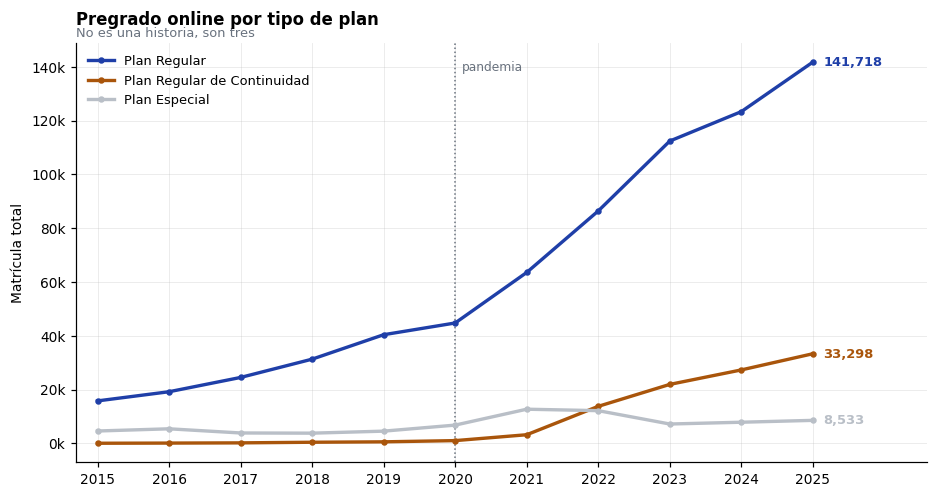

In [4]:
fig, ax = plt.subplots(figsize=(8.6, 4.6))
COL = {'Plan Regular': PALETA['foco'], 'Plan Regular de Continuidad': PALETA['lider'],
       'Plan Especial': PALETA['gris']}

for c in ['Plan Regular', 'Plan Regular de Continuidad', 'Plan Especial']:
    ax.plot(onl.index, onl[c], color=COL[c], lw=2.2, marker='o', ms=3.2, label=c)
    ax.annotate(f'{onl[c].iloc[-1]:,}', (onl.index[-1], onl[c].iloc[-1]),
                xytext=(7, 0), textcoords='offset points', fontsize=8.5,
                color=COL[c], va='center', fontweight='bold')

ax.axvline(2020, color=PALETA['suave'], lw=1, ls=':', zorder=1)
ax.text(2020.1, ax.get_ylim()[1]*.93, 'pandemia', fontsize=8, color=PALETA['suave'])
ax.set_ylabel('Matrícula total')
ax.yaxis.set_major_formatter(lambda x, p: f'{int(x/1000)}k')
ax.set_xticks(onl.index)
ax.set_xlim(2014.7, 2026.6)
ax.set_title('Pregrado online por tipo de plan', loc='left', fontweight='bold', pad=12)
ax.text(0, 1.015, 'No es una historia, son tres', transform=ax.transAxes,
        fontsize=8.5, color=PALETA['suave'])
ax.legend(fontsize=8.5, loc='upper left')
plt.tight_layout(); plt.show()

In [5]:
comp = pd.DataFrame({
    '2015': onl.loc[2015], '2019': onl.loc[2019], '2021': onl.loc[2021], '2025': onl.loc[2025],
})
comp['2015→2025_%'] = ((comp['2025'] / comp['2015'] - 1) * 100).round(0)
comp['2021→2025_%'] = ((comp['2025'] / comp['2021'] - 1) * 100).round(0)
comp

,2015,2019,2021,2025,2015→2025_%,2021→2025_%
tipo_plan,,,,,,
Plan Especial,4578,4523,12680,8533,86.0,-33.0
Plan Regular,15767,40373,63520,141718,799.0,123.0
Plan Regular de Continuidad,26,552,3191,33298,127969.0,943.0
TOTAL,20371,45448,79391,183549,801.0,131.0


Tres trayectorias distintas debajo de una sola palabra:

- **Plan Regular** es el motor: de 15.767 a 141.718. Solo entre 2021 y 2025 creció 123%.
- **Plan de Continuidad** no existía antes de 2015. Pasó de 26 alumnos a 33.298, y desde 2021
  creció 943%. Hoy es un quinto del pregrado online.
- **Plan Especial** —que en los años 2000 *era* el online— lleva cuatro años cayendo: −33% desde
  2021.

Decir "el online crece" esconde que uno de los tres se está muriendo.

Y el detalle que hace ruido en cualquier análisis de admisión: **los Planes de Continuidad no
reportan matrícula de primer año.** Son 33.298 alumnos online que desaparecen de cualquier vista
que use esa métrica.

## 3. La pandemia

Con cinco años de línea base antes de 2020, se puede preguntar si el vuelco a lo online fue un
salto pandémico o una tendencia que ya venía.

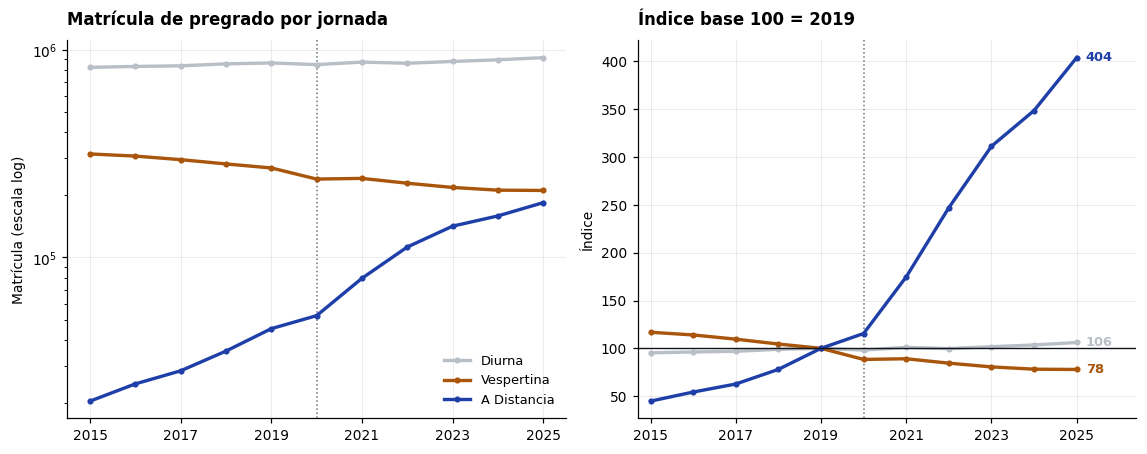

In [6]:
jor = serie_por(s, 'jornada', nivel_global='Pregrado')
jor = jor[['Diurna', 'Vespertina', 'A Distancia']]
idx = indexar(jor, base=2019)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))

CJ = {'Diurna': PALETA['gris'], 'Vespertina': PALETA['lider'], 'A Distancia': PALETA['foco']}
for c in jor.columns:
    axes[0].plot(jor.index, jor[c], color=CJ[c], lw=2.2, marker='o', ms=3, label=c)
axes[0].set_yscale('log')
axes[0].set_title('Matrícula de pregrado por jornada', loc='left', fontweight='bold', pad=10)
axes[0].set_ylabel('Matrícula (escala log)')
axes[0].legend(fontsize=8.5)

for c in idx.columns:
    axes[1].plot(idx.index, idx[c], color=CJ[c], lw=2.2, marker='o', ms=3, label=c)
    axes[1].annotate(f'{idx[c].iloc[-1]:.0f}', (idx.index[-1], idx[c].iloc[-1]),
                     xytext=(6, 0), textcoords='offset points', fontsize=8.5,
                     color=CJ[c], va='center', fontweight='bold')
axes[1].axhline(100, color=PALETA['tinta'], lw=.9)
axes[1].set_title('Índice base 100 = 2019', loc='left', fontweight='bold', pad=10)
axes[1].set_ylabel('Índice')
axes[1].set_xlim(2014.7, 2026.4)

for ax in axes:
    ax.axvline(2020, color=PALETA['suave'], lw=1, ls=':', zorder=1)
    ax.set_xticks(range(2015, 2026, 2))

plt.tight_layout(); plt.show()

In [7]:
tramos = pd.DataFrame({
    'pre-pandemia 2015→2019_%': ((jor.loc[2019] / jor.loc[2015]) ** (1/4) - 1) * 100,
    'salto 2019→2020_%':        (jor.loc[2020] / jor.loc[2019] - 1) * 100,
    'post 2020→2025_%':         ((jor.loc[2025] / jor.loc[2020]) ** (1/5) - 1) * 100,
}).round(1)
tramos.columns = ['crec. anual pre', 'salto 2020', 'crec. anual post']
tramos

,crec. anual pre,salto 2020,crec. anual post
jornada,,,
Diurna,1.2,-1.8,1.6
Vespertina,-3.8,-11.6,-2.5
A Distancia,22.2,15.5,28.4


Los tres tramos desmienten la explicación fácil.

Lo online **ya crecía al 22,2% anual antes de la pandemia.** El año 2020 fue, de hecho, su año más
lento del período: +15,5%, por debajo de su propia tendencia previa. Después se aceleró a 28,4%
anual. La pandemia no inauguró nada y ni siquiera fue el punto de inflexión: la curva ya estaba
disparada desde 2015.

El vespertino tampoco empezó a caer en 2020: **ya venía perdiendo 3,8% al año antes de la
pandemia.** Lo que hizo 2020 fue profundizar la caída —11,6% en un año— y de ahí no se recuperó,
sigue perdiendo 2,5% anual. Es la única jornada bajo su nivel de 2019.

Y el diurno, que uno esperaría hundido por la pandemia, apenas cedió 1,8% en 2020 y volvió a crecer
al 1,6% anual, más rápido que antes.

**La lectura correcta no es "la pandemia empujó a la gente al online".** Es que el vespertino y el
online compiten por el mismo estudiante —el que trabaja— y el online lo viene ganando desde antes.
La pandemia aceleró un traspaso que ya estaba en curso. Atribuírselo a ella es datar mal el
fenómeno y, con eso, equivocar el diagnóstico.

## 4. La trampa del denominador

Antes de mirar participaciones: el sistema no tiene los mismos jugadores en 2015 y en 2025.

In [8]:
instituciones_por_anio(s)

,anio,instituciones,entran,salen,salieron
0,2015,156,NaN,NaN,
1,2016,150,0.0,6.0,"CFT CEPONAL, CFT CRECIC, CFT CROWNLIET"
2,2017,148,2.0,4.0,"CFT BARROS ARANA, CFT CEPA DE LA III REGION, C..."
3,2018,146,3.0,5.0,"CFT LOS LEONES, CFT MAGNOS, CFT SIMON BOLIVAR"
4,2019,143,5.0,8.0,"CFT DUOC UC, CFT FINNING, CFT UDA"
5,2020,143,6.0,6.0,"CFT BARROS ARANA, CFT CEITEC, CFT LUIS ALBERTO..."
6,2021,138,4.0,9.0,"CFT ALFA, CFT ANDRES BELLO, CFT ESTUDIO PROFES..."
7,2022,136,3.0,5.0,"CFT BARROS ARANA, CFT CEITEC, IP DE ARTES ESCE..."
8,2023,131,1.0,6.0,CFT CENTRO DE ENSEÑANZA DE ALTA COSTURA PAULIN...
9,2024,128,1.0,4.0,"CFT LOS LAGOS, CFT MASSACHUSETTS, IP LOS LAGOS"


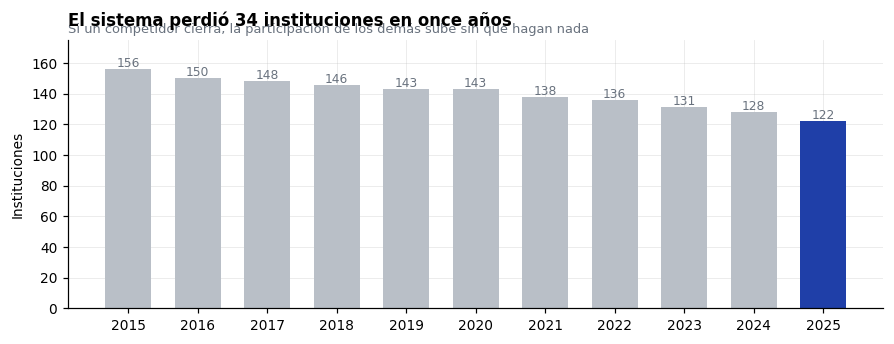

In [9]:
ins = instituciones_por_anio(s)

fig, ax = plt.subplots(figsize=(8.2, 3.2))
ax.bar(ins.anio, ins.instituciones, color=PALETA['gris'], width=.66)
ax.bar([2025], [ins.instituciones.iloc[-1]], color=PALETA['foco'], width=.66)
for _, r in ins.iterrows():
    ax.text(r.anio, r.instituciones + 1.5, int(r.instituciones), ha='center', fontsize=8,
            color=PALETA['suave'])
ax.set_ylabel('Instituciones')
ax.set_xticks(ins.anio)
ax.set_title('El sistema perdió 34 instituciones en once años',
             loc='left', fontweight='bold', pad=10)
ax.text(0, 1.03, 'Si un competidor cierra, la participación de los demás sube sin que hagan nada',
        transform=ax.transAxes, fontsize=8.5, color=PALETA['suave'])
ax.set_ylim(0, ins.instituciones.max() * 1.12)
plt.tight_layout(); plt.show()

De 156 a 122. **Cualquier alza de participación en este período puede ser un competidor que cerró,
no una victoria.** Es la advertencia más importante de este notebook y la que hay que poner en la
lámina, no en el pie de página.

## 5. De dónde viene el crecimiento de UNAB

Acá está la pregunta que importa para gestión: UNAB creció, pero ¿creció porque el mercado creció,
o porque le ganó al mercado?

La descomposición shift-share separa las dos cosas.

In [10]:
r = shift_share(s, foco=UNAB, anio0=2019, anio1=2025, universo='Universidades', nivel='Pregrado')

print(f"UNAB pregrado, universidades, 2019 → 2025")
print(f"  {r['V0']:,}  →  {r['V1']:,}   (Δ {r['delta']:+,})")
print()
print(r['descomposicion'].map(lambda v: f'{v:+,.0f}').to_string())
print()
print(f"  mercados comunes      : {r['mercados_comunes']}")
print(f"  mercados nuevos       : {r['mercados_nuevos']}")
print(f"  mercados abandonados  : {r['mercados_abandonados']}")

UNAB pregrado, universidades, 2019 → 2025
  45,041  →  59,286   (Δ +14,245)

efecto mercado                 +4,338
efecto participación           +2,015
interacción                    -2,351
entradas a mercados nuevos    +11,512
salidas de mercados            -1,269

  mercados comunes      : 137
  mercados nuevos       : 49
  mercados abandonados  : 30


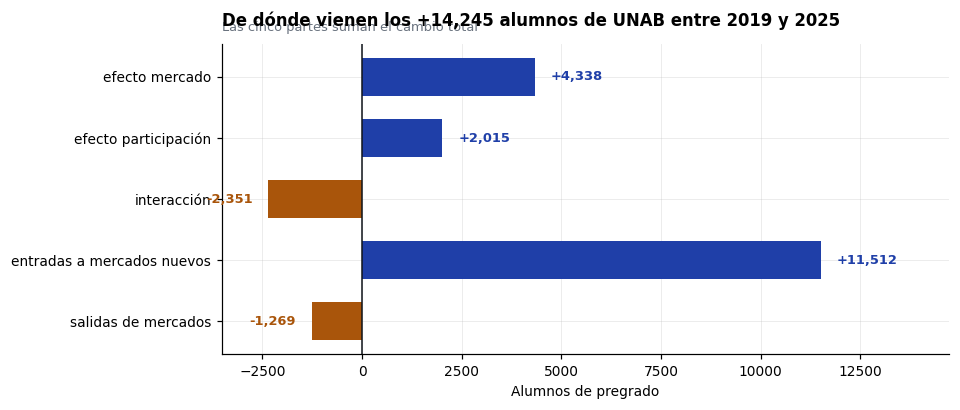

In [11]:
d = r['descomposicion']
etiquetas = list(d.index)
valores = d.values

fig, ax = plt.subplots(figsize=(8.8, 3.8))
colores = [PALETA['foco'] if v >= 0 else PALETA['lider'] for v in valores]
ax.barh(range(len(d)), valores, color=colores, height=.62)
ax.axvline(0, color=PALETA['tinta'], lw=1)
ax.set_yticks(range(len(d)), etiquetas, fontsize=9)
ax.invert_yaxis()
for i, v in enumerate(valores):
    ax.text(v + (400 if v >= 0 else -400), i, f'{v:+,.0f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=8.5, fontweight='bold',
            color=PALETA['foco'] if v >= 0 else PALETA['lider'])
ax.set_xlabel('Alumnos de pregrado')
ax.set_title(f"De dónde vienen los {r['delta']:+,} alumnos de UNAB entre 2019 y 2025",
             loc='left', fontweight='bold', pad=12)
ax.text(0, 1.04, 'Las cinco partes suman el cambio total', transform=ax.transAxes,
        fontsize=8.5, color=PALETA['suave'])
ax.set_xlim(valores.min() * 1.5, valores.max() * 1.28)
plt.tight_layout(); plt.show()

**El 81% del crecimiento de UNAB viene de entrar a mercados donde no estaba.**

De los 14.245 alumnos que ganó entre 2019 y 2025, 11.512 vienen de 49 mercados nuevos. Solo 2.015
vienen de ganar participación donde ya competía, y ese número hay que mirarlo con desconfianza:
en el mismo período desaparecieron 34 instituciones, y esta descomposición no distingue entre
ganar participación y heredarla de un competidor que cerró.

El efecto mercado —crecer porque el sistema creció— aporta 4.338. La interacción es negativa
(−2.351): UNAB perdió participación justo en los mercados que más crecieron.

**La estrategia de UNAB en estos seis años fue de expansión de oferta, no de conquista.** Abrió
programas nuevos. No le ganó a nadie donde ya estaba.

In [12]:
det = r['detalle'].copy()
det['delta'] = det.V1 - det.V0
peor = det.nsmallest(6, 'ef_share')[['V0', 'V1', 'S0', 'S1', 'ef_share']]
peor[['S0', 'S1']] = (peor[['S0', 'S1']] * 100).round(1)
print('Donde más participación perdió UNAB (2019 → 2025):')
print(peor.round(0).to_string())

Donde más participación perdió UNAB (2019 → 2025):
                                                                                V0      V1    S0    S1  ef_share
area_generica                                     region        jornada                                         
Ingeniería Comercial                              Metropolitana Diurna      2093.0  1501.0   9.0   6.0    -645.0
Bachillerato y/o Licenciatura en Ciencias Básicas Metropolitana Diurna       392.0    14.0  15.0   0.0    -379.0
Terapia Ocupacional                               Metropolitana Diurna       657.0   347.0  13.0   8.0    -280.0
Nutrición y Dietética                             Metropolitana Diurna       775.0   408.0  14.0   9.0    -278.0
Bachillerato y/o Licenciatura en Ciencias Básicas Valparaíso    Diurna       219.0     5.0  55.0   3.0    -209.0
Ingeniería Comercial                              Metropolitana Vespertina  1096.0   347.0  25.0  21.0    -192.0


In [13]:
mejor = det.nlargest(6, 'ef_share')[['V0', 'V1', 'S0', 'S1', 'ef_share']]
mejor[['S0', 'S1']] = (mejor[['S0', 'S1']] * 100).round(1)
print('Donde más participación ganó UNAB (2019 → 2025):')
print(mejor.round(0).to_string())

Donde más participación ganó UNAB (2019 → 2025):
                                                                                     V0     V1    S0     S1  ef_share
area_generica                                           region        jornada                                        
Administración de Empresas e Ing. Asociadas             Metropolitana Vespertina  729.0  316.0  18.0   38.0     790.0
Psicopedagogía                                          Metropolitana Diurna       91.0   79.0  13.0   92.0     555.0
Administración de Empresas e Ing. Asociadas             Metropolitana Diurna      325.0  432.0  14.0   36.0     491.0
Ingeniería en Automatización, Instrumentación y Control Metropolitana Vespertina  112.0   66.0  20.0  100.0     445.0
Medicina Veterinaria                                    Valparaíso    Diurna      177.0  956.0  14.0   41.0     332.0
Ingeniería en Computación e Informática                 Metropolitana Vespertina  348.0  188.0  20.0   38.0     299.0


## 6. Qué queda anotado

**Sobre lo online**

- Pregrado online: de 20.371 (2015) a 183.549 (2025). Pasó del 1,7% al 13,8% del pregrado.
- Son tres trayectorias, no una: Plan Regular +799%, Continuidad de 26 a 33.298, Plan Especial
  −33% desde 2021.
- Ya crecía 22,2% anual antes de la pandemia, y 2020 fue su año más lento (+15,5%). La pandemia
  aceleró un traspaso en curso; no lo inauguró.
- El vespertino ya caía 3,8% anual antes de 2020. La pandemia profundizó la caída (−11,6% en un
  año), no la empezó. Es la única jornada bajo su nivel de 2019.

**Sobre UNAB**

- 45.041 → 59.286 alumnos de pregrado entre 2019 y 2025.
- El 81% de esa ganancia viene de abrir mercados nuevos, no de ganar donde ya estaba.
- La interacción negativa dice que perdió participación en los mercados que más crecieron.

**Lo que esta serie sigue sin poder decir**

- Si la participación ganada es mérito propio o herencia de los 34 competidores que cerraron. Para
  separarlo hay que mirar entrada y salida de instituciones mercado por mercado.
- Nada sobre precio, selectividad, marca o calidad. No están en esta base.
- Los Planes de Continuidad quedan fuera de cualquier lectura por primer año.

**Advertencia de método**

El SIES revisa cifras históricas de forma retroactiva. Esta serie sale del archivo con corte
15-07-2025: no compares estos números con los que bajaste el año pasado sin volver a generar la
serie desde el archivo actual.